# Projet de prédiction de temps de livraison des commades.


## Preparer l'environenment : 
- ### <span style="color:blue">Import necessary librairies </span>



<br><br>


In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

from haversine import haversine

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import KNNImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

from geopy.distance import geodesic
from scipy.stats import f_oneway

<br>

- ### <span style="color:green">Utils
<br>

In [2]:
def draw(df):
    plt.figure(figsize=(16, 20))  # augmenter la hauteur pour 7 subplots
    
    cols = ['temps_livraison_min',
            'distance_km',               
            'zone_temporelle',        
            'Type_of_vehicle',        
            'multiple_deliveries',    
            'Weatherconditions',      
            'Delivery_person_Age']
    
    for i, col in enumerate(cols):
        plt.subplot(4, 2, i + 1)  # 4 lignes × 2 colonnes = 8 places (7 utilisées)
        sns.histplot(df[col], bins=50, kde=True)
        plt.title(f'Distribution de {col}')
    
    plt.tight_layout()
    plt.show()

def draw_variable(df, variable):
    plt.figure(figsize=(10, 6))
    sns.histplot(df[variable], kde=True, bins=30, color='blue')
    plt.title(f"Distribution de {variable}")
    plt.xlabel(variable)
    plt.ylabel("Fréquence")
    plt.show()

def draw_boxplot_variable(df, variable):
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df[variable])
    plt.title(f"Valeurs aberrantes pour {variable}")
    plt.show()

def draw_categ(df, variable):
    plt.figure(figsize=(10, 6))
    df[variable].value_counts().plot(kind='bar')
    plt.title(f"Répartition des catégories pour {variable}")
    plt.show()

def draw_categ_impact(df, variable, cible):
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df[variable], y=df[cible])
    plt.title(f"Impact des catégories de {variable} sur Time_taken(min)")
    plt.xticks(rotation=45)
    plt.show()

def remove_outliers(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return df[(df[column] >= lower) & (df[column] <= upper)]    

def get_time_period(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'    

<br>

- ### <span style="color:blue">Extraire la DATA SET
<br>

In [3]:


df = pd.read_csv("train.csv")
print(df.head())



        ID Delivery_person_ID Delivery_person_Age Delivery_person_Ratings  \
0  0x4607     INDORES13DEL02                   37                     4.9   
1  0xb379     BANGRES18DEL02                   34                     4.5   
2  0x5d6d     BANGRES19DEL01                   23                     4.4   
3  0x7a6a    COIMBRES13DEL02                   38                     4.7   
4  0x70a2     CHENRES12DEL01                   32                     4.6   

   Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  \
0            22.745049             75.892471                   22.765049   
1            12.913041             77.683237                   13.043041   
2            12.914264             77.678400                   12.924264   
3            11.003669             76.976494                   11.053669   
4            12.972793             80.249982                   13.012793   

   Delivery_location_longitude  Order_Date Time_Orderd Time_Order_picked  \
0   

<br>

- ### <span style="color:blue">Trouver les NaN
<br>


In [4]:

df.replace({"NaN": np.nan}, regex=True, inplace = True)

print(df.isnull().sum())
print("Nombe des duplicats : ", df.duplicated().sum())

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weatherconditions               616
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken(min)                   0
dtype: int64
Nombe des duplicats :  0


<br>

- ### <span style="color:blue">Enlever les colonnes unutiles</span> <br>

In [5]:
df_set = df.copy();
colonnes_unutiles = ["ID", "Delivery_person_ID", "Festival"]

df_set.drop(columns=colonnes_unutiles, inplace=True)

df_set.head()


,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,City,Time_taken(min)
0,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,Urban,(min) 24
1,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,Metropolitian,(min) 33
2,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,Urban,(min) 26
3,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,Metropolitian,(min) 21
4,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,Metropolitian,(min) 30


<br>

## Personnaliser la Data Set    
- ### <span style="color:blue">Time_taken (cible)</span> <br>

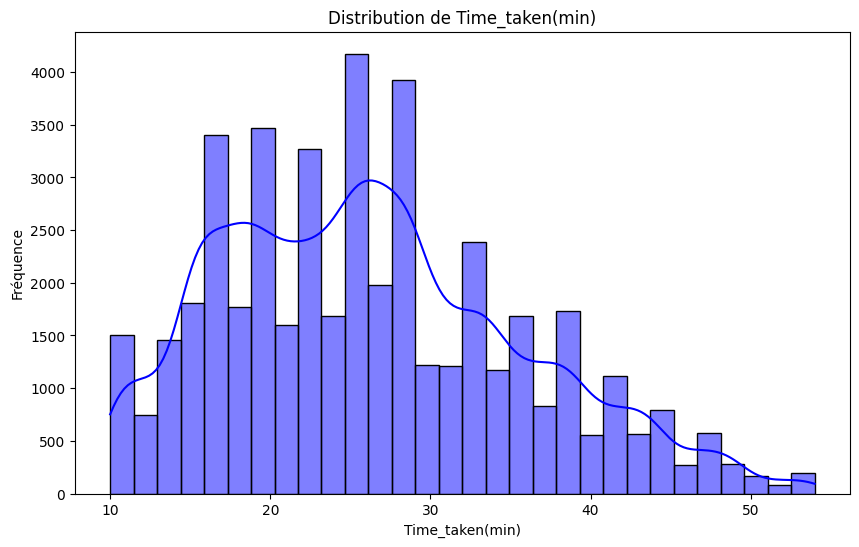

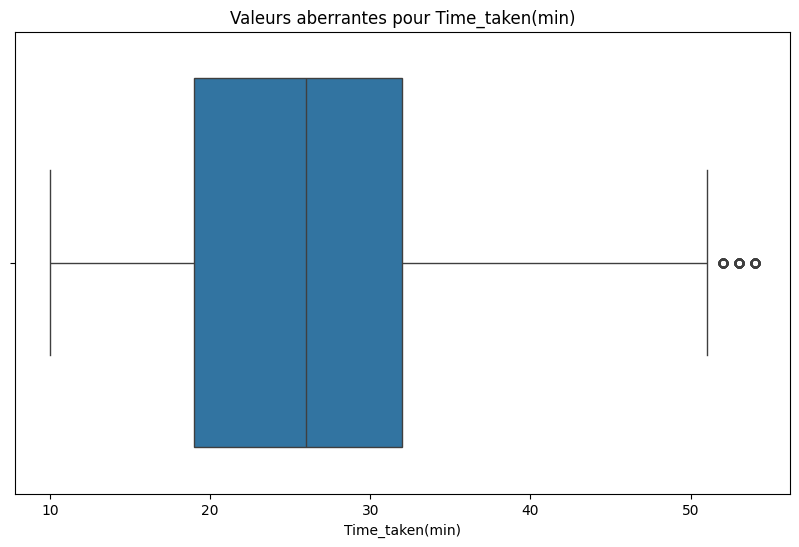

In [6]:
# Enlever (min) des valeurs 

df_set['Time_taken(min)'] = df_set['Time_taken(min)'].str.replace(r'\(min\)', '', regex=True).astype(float)

draw_variable(df_set, 'Time_taken(min)')
draw_boxplot_variable(df_set, 'Time_taken(min)')

- On consate quelque valeurs adherente au dela de 50 min, on doit les imputer

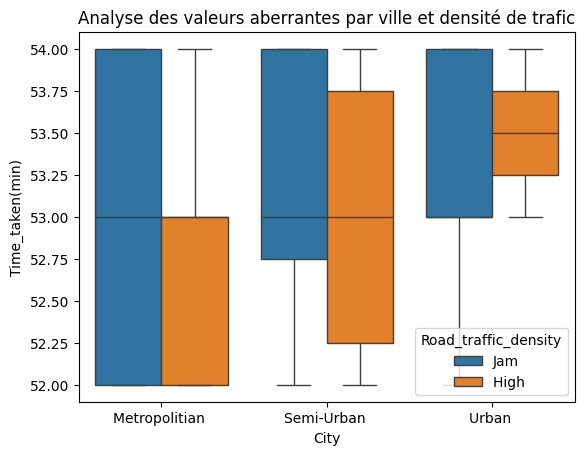

In [7]:
Q1 = df_set['Time_taken(min)'].quantile(0.25)
Q3 = df_set['Time_taken(min)'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Valeurs aberrantes
outliers = df_set[(df_set['Time_taken(min)'] < lower_bound) | (df_set['Time_taken(min)'] > upper_bound)]

df_set = df_set[(df_set['Time_taken(min)'] >= lower_bound) & (df_set['Time_taken(min)'] <= upper_bound)]


sns.boxplot(x='City', y='Time_taken(min)', data=outliers, hue='Road_traffic_density')
plt.title("Analyse des valeurs aberrantes par ville et densité de trafic")
plt.show()


<br>

## Personnaliser la Data Set    
- ### <span style="color:blue">Variables categorielles</span> <br>

- Weather conditions

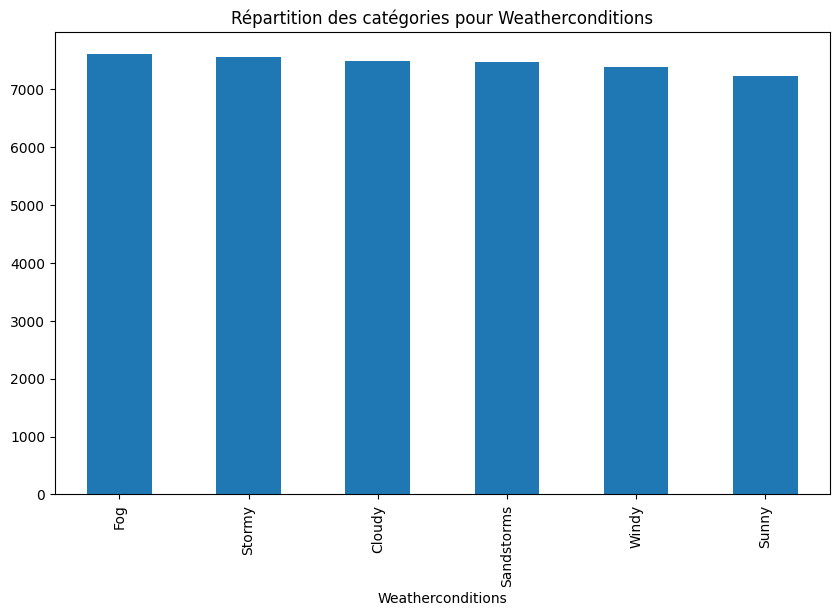

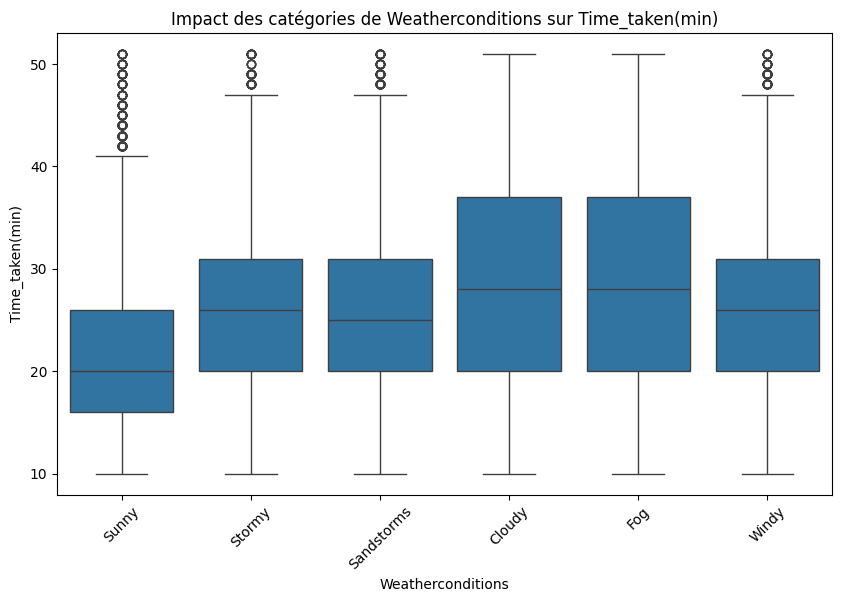

In [8]:
# Reformuler WeatherConditions
df_set['Weatherconditions'] = df_set['Weatherconditions'].str.replace(r'conditions\s*', '', regex=True)


draw_categ(df_set, 'Weatherconditions')
draw_categ_impact(df_set, 'Weatherconditions', 'Time_taken(min)')


In [9]:
# Analyser les valeurs abérentes dans la colonne weatherconditions

# Analyse des valeurs uniques et de leur fréquence
print(df_set['Weatherconditions'].value_counts())

# Proportion de valeurs manquantes
print(f"Proportion de valeurs manquantes : {df_set['Weatherconditions'].isnull().mean() * 100:.2f}%")


Weatherconditions
Fog           7597
Stormy        7549
Cloudy        7492
Sandstorms    7463
Windy         7378
Sunny         7233
Name: count, dtype: int64
Proportion de valeurs manquantes : 1.35%


In [10]:
# Imputation de weatherconditions
distribution = df_set['Weatherconditions'].value_counts(normalize=True)

missing_indices = df_set['Weatherconditions'][df_set['Weatherconditions'].isnull()].index
df_set.loc[missing_indices, 'Weatherconditions'] = np.random.choice(
    distribution.index, size=len(missing_indices), p=distribution.values
)

df_set.isnull().sum()


Delivery_person_Age            1837
Delivery_person_Ratings        1891
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1716
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density            596
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             990
City                           1198
Time_taken(min)                   0
dtype: int64

- Road_traffic_density

Road_traffic_density
Low        15477
Jam        13902
Medium     10947
High        4401
Name: count, dtype: int64
Proportion de valeurs manquantes : 1.32%


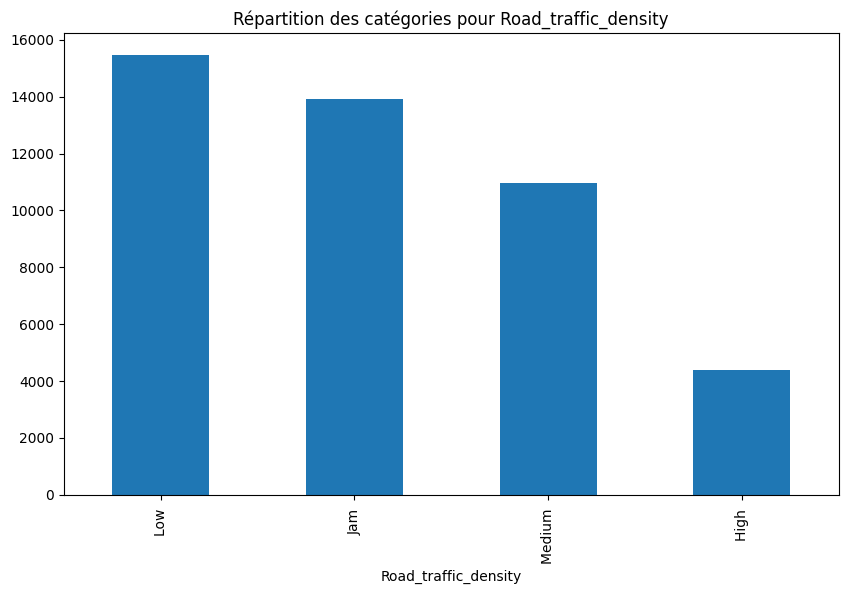

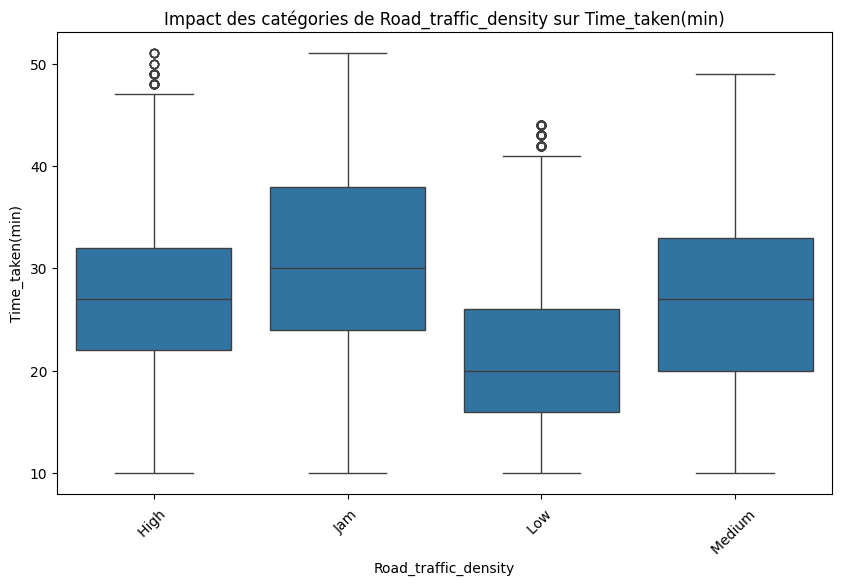

In [11]:
# Analyse des valeurs uniques et de leur fréquence
print(df_set['Road_traffic_density'].value_counts())

# Proportion de valeurs manquantes
print(f"Proportion de valeurs manquantes : {df_set['Road_traffic_density'].isnull().mean() * 100:.2f}%")

draw_categ(df_set, 'Road_traffic_density')
draw_categ_impact(df_set, 'Road_traffic_density', 'Time_taken(min)')

In [12]:
# Calcul des limites pour chaque catégorie de Road_traffic_density
categories = df_set['Road_traffic_density'].unique()
outliers = {}

for category in categories:
    subset = df_set[df_set['Road_traffic_density'] == category]['Time_taken(min)']
    Q1 = subset.quantile(0.25)
    Q3 = subset.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers[category] = subset[(subset < lower_bound) | (subset > upper_bound)]

# supression des valeurs abérentes
for category, values in outliers.items():
    # Remplacer les valeurs de Road_traffic_density par NaN pour les lignes correspondantes
    df_set.loc[
        (df_set['Road_traffic_density'] == category) & (df_set['Time_taken(min)'].isin(values)),
        'Road_traffic_density'
    ] = np.nan

print(df_set['Road_traffic_density'].isnull().sum())

829


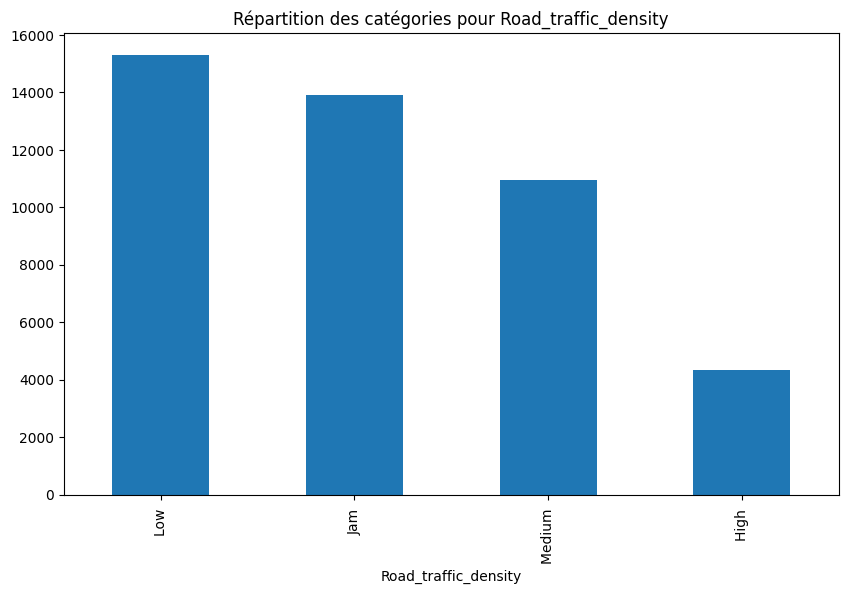

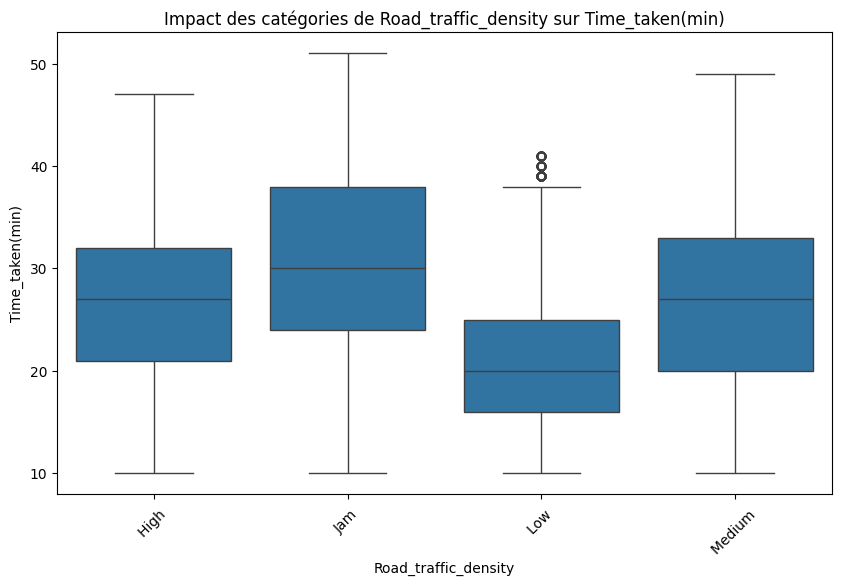

In [13]:
# Imputer les valeurs de Road traffic density
# df_set.update(df_set['Road_traffic_density'].fillna(df_set['Road_traffic_density'].mode()[0]))
draw_categ(df_set, 'Road_traffic_density')
draw_categ_impact(df_set, 'Road_traffic_density', 'Time_taken(min)')

- Type_of_order

Type_of_order
Snack      11458
Meal       11393
Drinks     11262
Buffet     11210
Name: count, dtype: int64


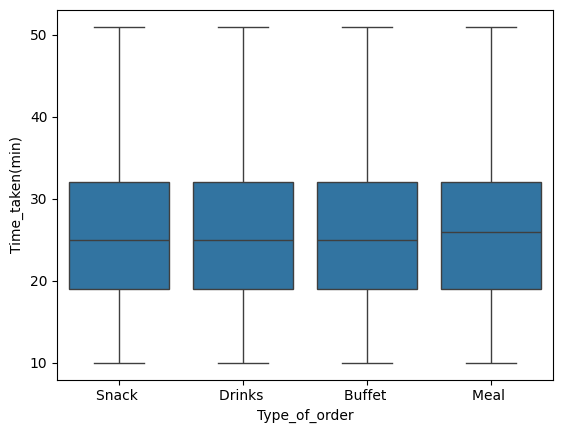

In [14]:
print(df_set['Type_of_order'].value_counts())

sns.boxplot(x='Type_of_order', y='Time_taken(min)', data=df_set)

# Eliminer la variable Type_of_order car elle n'est pas decisives
df_set = df_set.drop(columns=['Type_of_order'])


- Type_of_vehicle

Type_of_vehicle
motorcycle           26168
scooter              15274
electric_scooter      3813
bicycle                 68
Name: count, dtype: int64
Type_of_vehicle
motorcycle          26168
scooter             15274
electric_scooter     3813
Name: count, dtype: int64


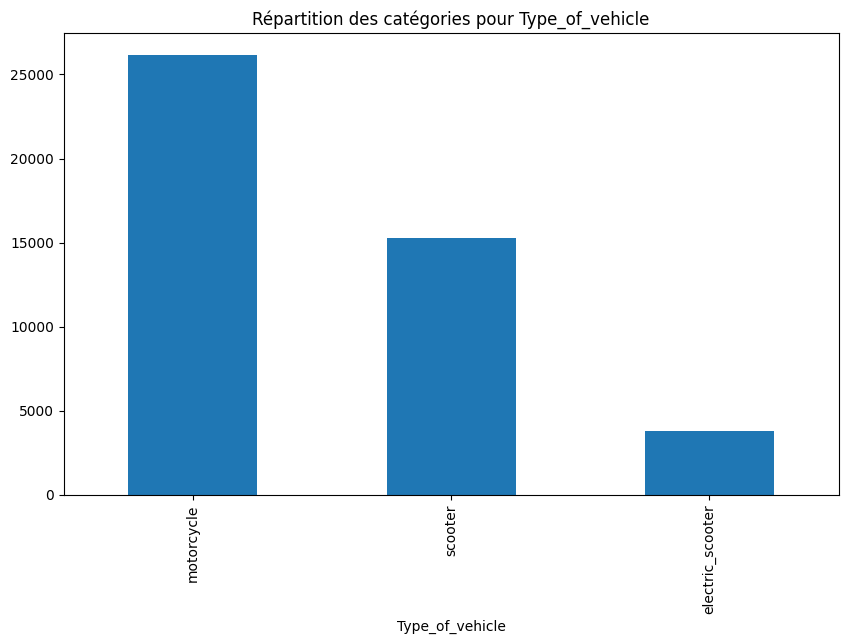

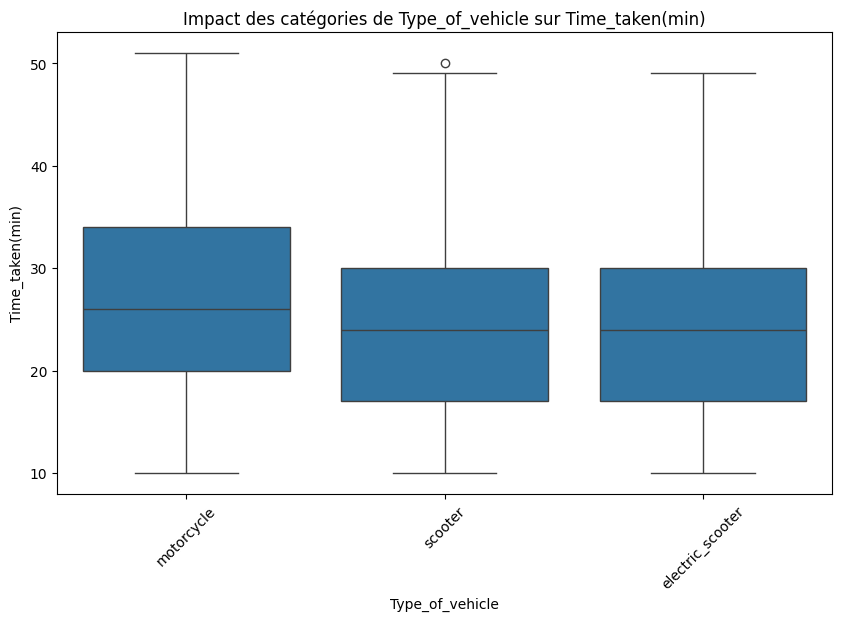

In [15]:
print(df_set['Type_of_vehicle'].value_counts())
df_set['Type_of_vehicle'] = df_set['Type_of_vehicle'].str.strip()
df_set = df_set[df_set['Type_of_vehicle'] != 'bicycle']

print(df_set['Type_of_vehicle'].value_counts())
draw_categ(df_set, 'Type_of_vehicle')
draw_categ_impact(df_set, "Type_of_vehicle", "Time_taken(min)")


- City

{'Urban': 275      50.0
285      47.0
413      49.0
447      48.0
479      50.0
         ... 
43922    49.0
44170    48.0
44738    49.0
45481    47.0
45576    48.0
Name: Time_taken(min), Length: 111, dtype: float64, 'Metropolitian': Series([], Name: Time_taken(min), dtype: float64), nan: Series([], Name: Time_taken(min), dtype: float64)}


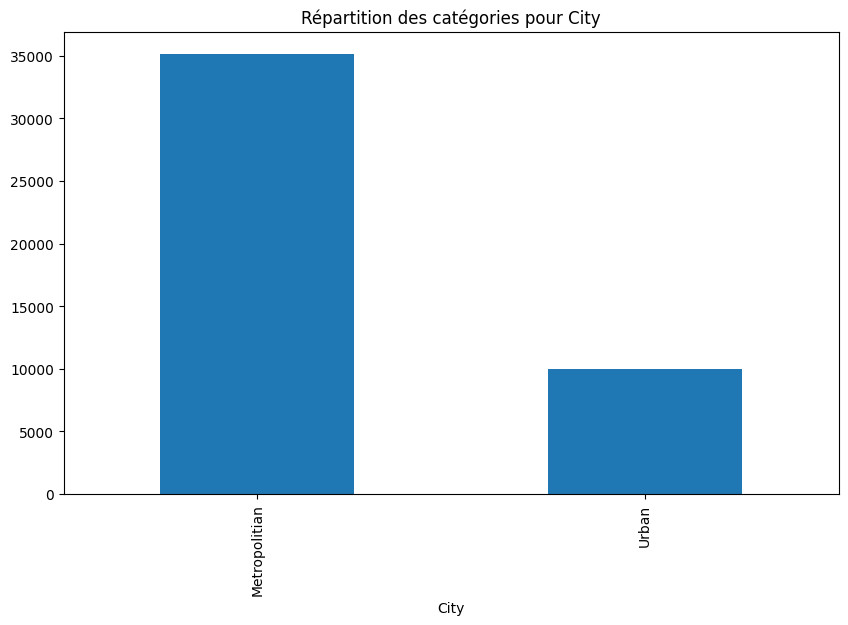

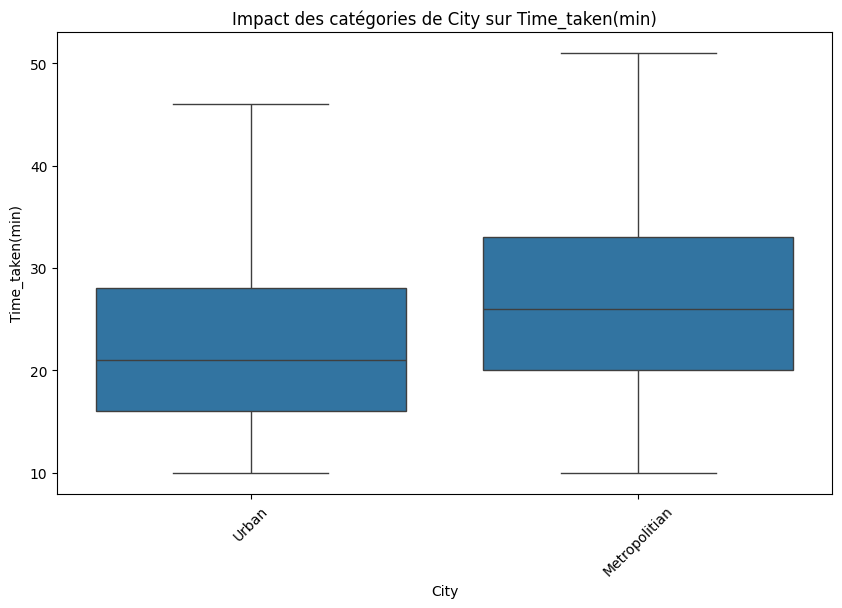

In [16]:
# enlever la baisement de semi-urban
df_set['City'] = df_set['City'].str.strip()
df_set = df_set[df_set['City'] != 'Semi-Urban']

# Capter les valeurs abérentes
categories = df_set['City'].unique()
outliers = {}

for category in categories:
    subset = df_set[df_set['City'] == category]['Time_taken(min)']
    Q1 = subset.quantile(0.25)
    Q3 = subset.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers[category] = subset[(subset < lower_bound) | (subset > upper_bound)]

print (outliers)

# imputer les valeurs abérentes par "Metropolitian"
for category, values in outliers.items():
    # Remplacer les valeurs de Road_traffic_density par NaN pour les lignes correspondantes
    df_set.loc[
        (df_set['City'] == category) & (df_set['Time_taken(min)'].isin(values)),
        'City'
    ] = 'Metropolitian'
# imputer les valeur null
df_set.update(df_set['City'].fillna(df_set['City'].mode()[0]))


draw_categ(df_set, 'City')
draw_categ_impact(df_set, "City", "Time_taken(min)")

- Myltipe_deliveries
  

In [17]:
print(df_set.multiple_deliveries.unique())
print(df_set.isnull().sum())
print(len(df_set))

['0' '1' '3' nan '2']
Delivery_person_Age            1776
Delivery_person_Ratings        1830
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1642
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density            751
Vehicle_condition                 0
Type_of_vehicle                   0
multiple_deliveries             989
City                              0
Time_taken(min)                   0
dtype: int64
45145


In [18]:
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import numpy as np

# Identifier les valeurs valides et aberrantes
valid_values = ['0', '1']
invalid_indices = ~df_set['multiple_deliveries'].isin(valid_values)  # Indices des valeurs invalides

# Convertir les valeurs invalides en NaN
df_set.loc[invalid_indices, 'multiple_deliveries'] = np.nan

# Sélectionner les colonnes nécessaires pour l'analyse
columns_to_encode = ['Vehicle_condition', 'Type_of_vehicle', 'City', 'Weatherconditions']
columns_to_keep = columns_to_encode + ['Time_taken(min)', 'multiple_deliveries']

# Créez une copie du DataFrame avec uniquement les colonnes nécessaires
df_selected = df_set[columns_to_keep]

# Encoder les colonnes catégoriques sélectionnées
df_encoded = pd.get_dummies(df_selected, columns=columns_to_encode, drop_first=True)

# Séparer les données complètes et les données avec valeurs à imputer
complete_rows = df_encoded[df_encoded['multiple_deliveries'].notnull()]
missing_rows = df_encoded[df_encoded['multiple_deliveries'].isnull()]

# Préparer X (features) et y (target)
X_complete = complete_rows.drop(columns=['multiple_deliveries'])
y_complete = complete_rows['multiple_deliveries'].astype(int)  # Convertir en int pour kNN

# Modèle kNN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_complete, y_complete)

# Prédire les valeurs manquantes (NaN ou valeurs aberrantes)
X_missing = missing_rows.drop(columns=['multiple_deliveries'])
predictions = knn.predict(X_missing)

# Mettre à jour les valeurs prédites dans le DataFrame original
df_set.loc[df_set['multiple_deliveries'].isnull(), 'multiple_deliveries'] = predictions.astype(str)

# Convertir toute la colonne en chaînes de caractères pour garantir la cohérence
df_set['multiple_deliveries'] = df_set['multiple_deliveries'].astype(str)

# Afficher les valeurs uniques après traitement
print(df_set['multiple_deliveries'].unique())



['0' '1']


In [19]:
print(df_set.isnull().sum())

Delivery_person_Age            1776
Delivery_person_Ratings        1830
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1642
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density            751
Vehicle_condition                 0
Type_of_vehicle                   0
multiple_deliveries               0
City                              0
Time_taken(min)                   0
dtype: int64


- Vehicle_condition

In [20]:
df_set = df_set.drop(columns=['Vehicle_condition'])

<br>

- ### <span style="color:blue">Variables numériques</span> <br>
- Delivery_person_Age

In [21]:
# Change type
df_set['Delivery_person_Age']=df_set['Delivery_person_Age'].astype(float)

# Imputer les valeurs null
df_set['Delivery_person_Age']= df_set['Delivery_person_Age'].fillna(df_set.Delivery_person_Age.median())

# Eliminer les valeurs illogique
df_set = df_set.loc[(df_set['Delivery_person_Age'] >= 18) & (df_set['Delivery_person_Age'] <= 45)]

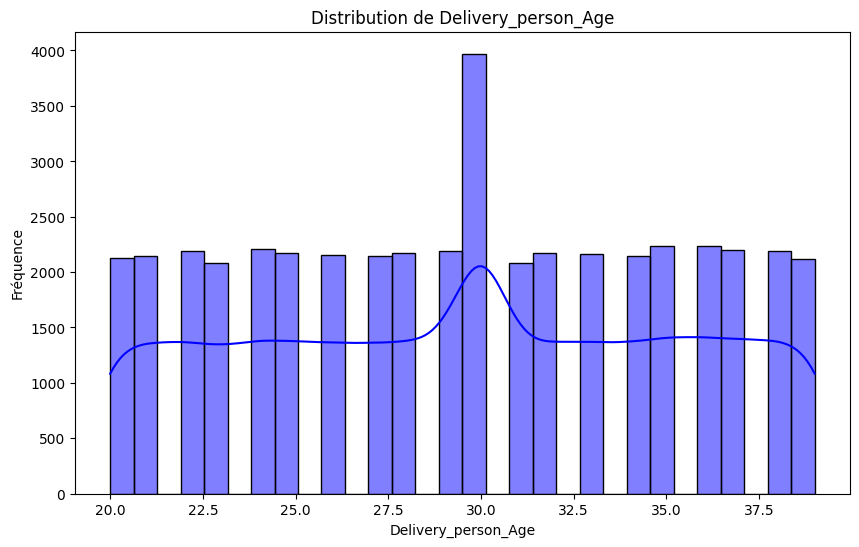

In [22]:
draw_variable(df_set, 'Delivery_person_Age')

- Delivery_person_Ratings

In [23]:
# Change type
df_set['Delivery_person_Ratings']=df_set['Delivery_person_Ratings'].astype(float)

In [24]:
df_set['Delivery_person_Ratings']=df_set['Delivery_person_Ratings'].fillna(df_set.Delivery_person_Ratings.median())

In [25]:
print(df_set.isnull().sum())

Delivery_person_Age               0
Delivery_person_Ratings           0
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1566
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density            675
Type_of_vehicle                   0
multiple_deliveries               0
City                              0
Time_taken(min)                   0
dtype: int64


<br>

- ### <span style="color:blue">Variables temporelles</span> <br>
- Order_Date

In [26]:
# Conversion des colonnes temporelles
df_set['Order_Date'] = pd.to_datetime(df_set['Order_Date'], format='%d-%m-%Y', errors='coerce')

- Time_Orderd

In [27]:
# Supprimer les données illogiques quand le temps de commande et superieur au celui de prise de commade
# Ajouter une date fictive pour effectuer la conversion
df_set['Time_Orderd'] = pd.to_datetime('2023-01-01 ' + df_set['Time_Orderd'], errors='coerce')
df_set['Time_Order_picked'] = pd.to_datetime('2023-01-01 ' + df_set['Time_Order_picked'], errors='coerce')

# Conversion explicite des colonnes avec un format spécifié
df_set['Time_Orderd'] = pd.to_datetime(df_set['Time_Orderd'], errors='coerce')
df_set['Time_Order_picked'] = pd.to_datetime(df_set['Time_Order_picked'], errors='coerce')

In [28]:
#Imputer les valeurs manquantes de time_orderd
df_set.update(df_set['Time_Orderd'].fillna(df_set['Time_Orderd'].median()))

# Suppression des lignes où `Time_Order_Picked` est avant `Time_Order`
df_set = df_set[df_set['Time_Order_picked'] >= df_set['Time_Orderd']]

# Supprimer Time_Orderd car il n'est plus utile
df_set = df_set.drop(columns=['Time_Orderd'])

In [29]:
df_set.isnull().sum()

Delivery_person_Age              0
Delivery_person_Ratings          0
Restaurant_latitude              0
Restaurant_longitude             0
Delivery_location_latitude       0
Delivery_location_longitude      0
Order_Date                       0
Time_Order_picked                0
Weatherconditions                0
Road_traffic_density           409
Type_of_vehicle                  0
multiple_deliveries              0
City                             0
Time_taken(min)                  0
dtype: int64

- Time_Order_picked

In [30]:
# Creating two new column for hours
df_set['Hour_order_picked']=df_set['Time_Order_picked'].dt.hour

<br>

## Features Engineering
<br>

<br>

- ### <span style="color:blue">Variables temporelles</span> <br>
- isWeekend

In [31]:
# Extraire les jours des livraisons
df_set['Order_Weekday'] = df_set['Order_Date'].dt.day_name()

# Ajouter la nouvelle valeur pour savoir si la livraison a été faite au weekend
df_set['Is_Weekend'] = df_set['Order_Weekday'].apply(lambda x: 1 if x in ['Saturday', 'Sunday'] else 0)

# Supprimer les variables unitiles
df_set = df_set.drop(columns=['Order_Date', 'Order_Weekday'])

- delivery_time

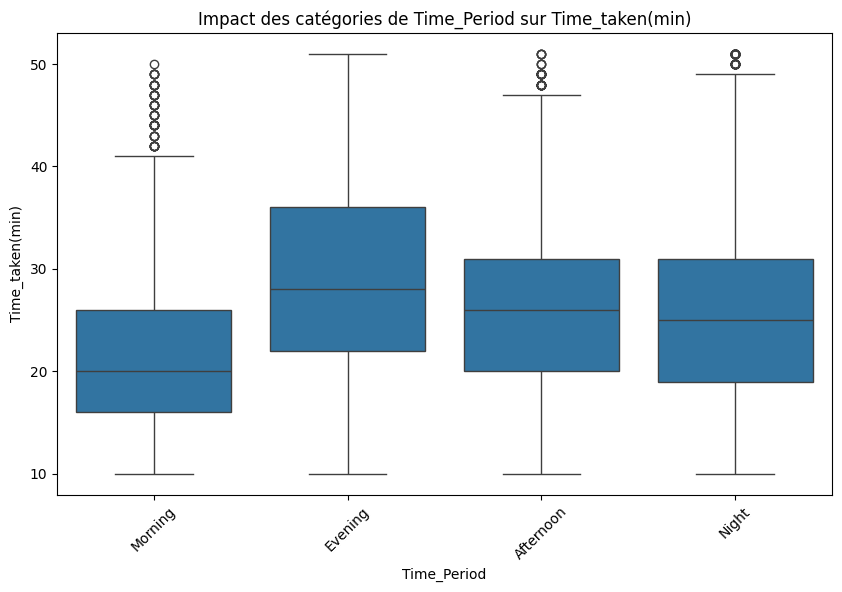

In [32]:
# Ajouter la nouvelle variable pour la plage horaire de livraison
df_set['Time_Period'] = df_set['Hour_order_picked'].apply(get_time_period)
draw_categ_impact(df_set, 'Time_Period', 'Time_taken(min)')

<br>

- ### <span style="color:blue">Variables numériques</span> <br>
- Distance_metre

In [33]:

# Define a function to calculate distance
def calculate_distance(row):
    restaurant_coords = (row['Restaurant_latitude'], row['Restaurant_longitude'])
    delivery_coords = (row['Delivery_location_latitude'], row['Delivery_location_longitude'])
    return geodesic(restaurant_coords, delivery_coords).kilometers

# Apply the function to the DataFrame
df_set['distance_km'] = df_set.apply(calculate_distance, axis=1)


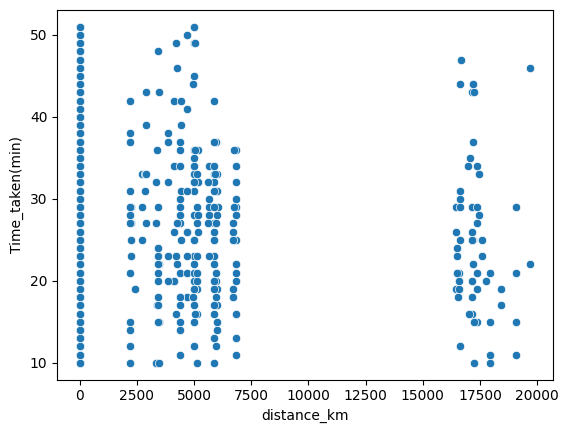

In [34]:
sns.scatterplot(data=df_set, x='distance_km', y='Time_taken(min)')
plt.show()

In [35]:
# eliminer les distances illogiques
df_set = df_set[df_set['distance_km'] <20]

<br>

- ### <span style="color:blue">Variables restantes</span> <br>
- Road_traffic_density

In [36]:
# imputer les variables null
probs = df_set['Road_traffic_density'].value_counts(normalize=True)
df_set['Road_traffic_density'] = df_set['Road_traffic_density'].apply(lambda x: np.random.choice(probs.index, p=probs.values) if pd.isnull(x) else x)

df_set.isnull().sum()

Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Type_of_vehicle                0
multiple_deliveries            0
City                           0
Time_taken(min)                0
Hour_order_picked              0
Is_Weekend                     0
Time_Period                    0
distance_km                    0
dtype: int64

<br>

## Encoder les variables categorielles
<br>

In [37]:
df_set.select_dtypes(include='object').columns
columns = ['Weatherconditions', 'Road_traffic_density', 'Type_of_vehicle',
       'multiple_deliveries', 'City', 'Time_Period']

In [38]:
# Choisir l'encoder
oe = OrdinalEncoder()

In [39]:
df_encoded = df_set.copy()

df_encoded[['Weatherconditions', 'Road_traffic_density', 'Type_of_vehicle', 
       'multiple_deliveries', 'City', 'Time_Period']] = oe.fit_transform(df_encoded[['Weatherconditions', 'Road_traffic_density', 'Type_of_vehicle',
       'multiple_deliveries', 'City', 'Time_Period']])



In [40]:
for col in columns:
    print(df_encoded[col].unique())

[4. 2. 0. 1. 3. 5.]
[0. 2. 3. 1.]
[1. 2. 0.]
[0. 1.]
[1. 0.]
[2. 1. 0. 3.]


<br>

## Calculer la correlation
<br>

In [41]:
df_encoded.dtypes

Delivery_person_Age                   float64
Delivery_person_Ratings               float64
Restaurant_latitude                   float64
Restaurant_longitude                  float64
Delivery_location_latitude            float64
Delivery_location_longitude           float64
Time_Order_picked              datetime64[ns]
Weatherconditions                     float64
Road_traffic_density                  float64
Type_of_vehicle                       float64
multiple_deliveries                   float64
City                                  float64
Time_taken(min)                       float64
Hour_order_picked                       int32
Is_Weekend                              int64
Time_Period                           float64
distance_km                           float64
dtype: object

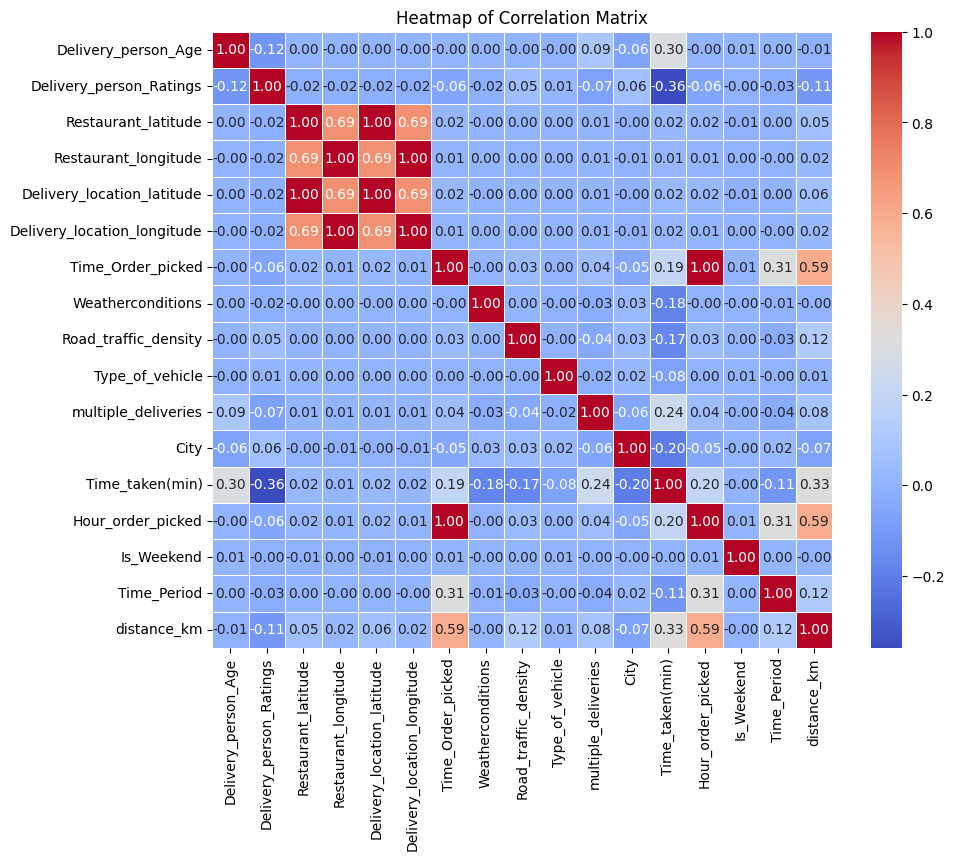

In [42]:
# Calculer la matrice de corrélation
correlation_matrix = df_encoded.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap of Correlation Matrix')
plt.show()

<br>

## Preparer le modèle
<br>

In [43]:
df_model = df_encoded.copy()
df_model.isnull().sum()

Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Type_of_vehicle                0
multiple_deliveries            0
City                           0
Time_taken(min)                0
Hour_order_picked              0
Is_Weekend                     0
Time_Period                    0
distance_km                    0
dtype: int64

In [44]:
# renommer le nom de variable cible
df_model = df_model.rename(columns={'Time_taken(min)':'Time_taken'})

# Preparer x, y
x= df_model.drop(['Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Time_Order_picked', 'Time_taken'],axis=1)
y= df_model.Time_taken

In [45]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [46]:
x_train.dtypes

Delivery_person_Age        float64
Delivery_person_Ratings    float64
Weatherconditions          float64
Road_traffic_density       float64
Type_of_vehicle            float64
multiple_deliveries        float64
City                       float64
Hour_order_picked            int32
Is_Weekend                   int64
Time_Period                float64
distance_km                float64
dtype: object

<br>

## Normaliser la data set
<br>

In [47]:
sc = StandardScaler()

In [48]:
sc.fit(x_train)

StandardScaler()

In [49]:
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

<br>

## Appliquer le modèle Random Forest Regressor
<br>

In [50]:
rfr = RandomForestRegressor(max_depth=10, n_estimators=100, random_state=42)

In [51]:
rfr.fit(x_train,y_train)

RandomForestRegressor(max_depth=10, random_state=42)

In [52]:
rfr_pred = rfr.predict(x_test)

In [53]:
print(r2_score(y_test,rfr_pred))

0.7592732704869171


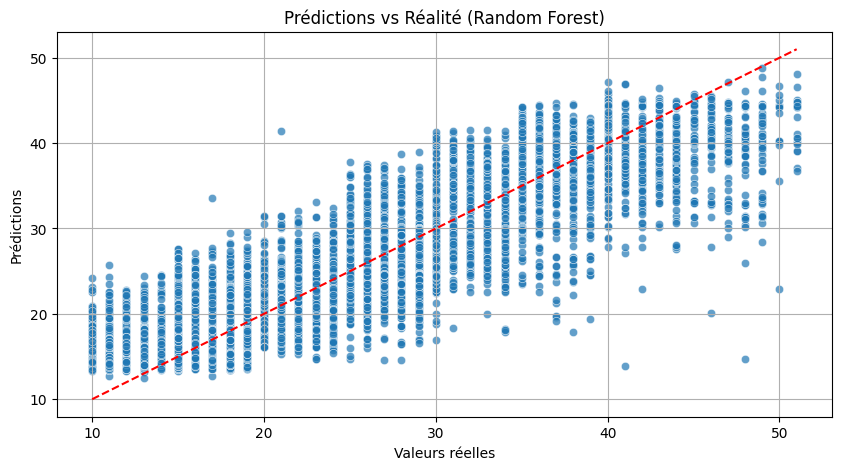

In [54]:
plt.figure(figsize=(10,5))
sns.scatterplot(x=y_test, y=rfr_pred, alpha=0.7)
plt.xlabel("Valeurs réelles")
plt.ylabel("Prédictions")
plt.title("Prédictions vs Réalité (Random Forest)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.grid()
plt.show()